# Individual Model Implementation: Support Vector Machine (SVM)
## Adult Income Prediction Project

- **Student ID:** IT25103014
- **Student Name:** Weerarathna N.H
- **Assigned Model:** Support Vector Machine (`sklearn.svm.SVC`)
- **Dataset:** Adult Income Dataset (`data/raw/adult.csv`)
- **Target Feature:** `income` (`<=50K` [0] vs `>50K` [1])
- **Group ID:** 2026-Y2-S1-MLB-B1G1-07

---

### Notebook Purpose & Academic Scope
This notebook implements, evaluates, tunes, and interprets an independent Support Vector Machine classification model for predicting whether an individual earns more than $50,000 annually. The entire pipeline is built self-contained, strictly adhering to group preprocessing agreements while preventing data leakage through Scikit-Learn `Pipeline` and `ColumnTransformer` encapsulation.

## 1. Imports and Environment Configuration
We load standard numerical processing, data analysis, machine learning, and visualization libraries. Standard plotting styles and seeds are configured for deterministic reproducibility.

In [1]:
import os
import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn components
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Plotting configuration
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150

# Repository directory paths resolution
# Ensures correct execution whether launched from repo root or notebooks/models/
cwd = Path.cwd().resolve()
if (cwd / 'data' / 'raw' / 'adult.csv').exists():
    REPO_ROOT = cwd
elif (cwd.parent / 'data' / 'raw' / 'adult.csv').exists():
    REPO_ROOT = cwd.parent
elif (cwd.parent.parent / 'data' / 'raw' / 'adult.csv').exists():
    REPO_ROOT = cwd.parent.parent
else:
    REPO_ROOT = Path('.').resolve()

DATA_RAW_PATH = REPO_ROOT / 'data' / 'raw' / 'adult.csv'
OUTPUT_FIGURES_DIR = REPO_ROOT / 'results' / 'eda_visualizations' / 'models'
OUTPUT_RESULTS_DIR = REPO_ROOT / 'results' / 'model_results'

OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository Root: {REPO_ROOT}")
print(f"Raw Dataset Path: {DATA_RAW_PATH}")
print(f"Model Figures Directory: {OUTPUT_FIGURES_DIR}")
print(f"Model Results Directory: {OUTPUT_RESULTS_DIR}")


Repository Root: C:\Users\Malan\Documents\Academic\Y2S1\AIML\AI Project\predicting-adult-income-level
Raw Dataset Path: C:\Users\Malan\Documents\Academic\Y2S1\AIML\AI Project\predicting-adult-income-level\data\raw\adult.csv
Model Figures Directory: C:\Users\Malan\Documents\Academic\Y2S1\AIML\AI Project\predicting-adult-income-level\results\eda_visualizations\models
Model Results Directory: C:\Users\Malan\Documents\Academic\Y2S1\AIML\AI Project\predicting-adult-income-level\results\model_results


## 2. Load the Raw Adult Income Dataset
We load the original assigned `data/raw/adult.csv` dataset. The dataset contains demographic and employment features recorded from the 1994 US Census database.

In [2]:
# Load original raw dataset
df_raw = pd.read_csv(DATA_RAW_PATH)
df = df_raw.copy()

print(f"Raw Dataset Dimensions: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Features: {list(df.columns)}")
df.head()


Raw Dataset Dimensions: 32,561 rows, 15 columns
Features: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 3. Deterministic Data Cleaning & Pre-Split Preparation
Following group conventions established in earlier preprocessing reviews:
1. Strip leading and trailing whitespace from string/object values.
2. Replace literal `'?'` missing-value placeholders with `np.nan`.
3. Detect and remove exact duplicate records to prevent record duplication and data leakage across splits.
4. Remove redundant `education` column: Group engineering analysis (IT25300115) confirmed that `education` is an exact 1-to-1 functional equivalent to `education.num` (16 educational tiers). Retaining both introduces collinear structural duplication. We retain `education.num` and drop `education`.
5. Map binary target: `'<=50K'` -> `0`, `'>50K'` -> `1`.

> **Data Leakage Safeguard:** No statistical imputation, scaling, or One-Hot Encoding is fitted prior to the train/test split.

In [3]:
# 1. Strip string whitespace
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].astype(str).str.strip()

# 2. Replace '?' placeholders with np.nan
df.replace('?', np.nan, inplace=True)

# 3. Exact duplicate removal
initial_rows = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
dropped_duplicates = initial_rows - len(df)
print(f"Removed exact duplicate records: {dropped_duplicates} rows")

# 4. Redundancy removal: drop 'education' and retain 'education.num'
if 'education' in df.columns:
    df.drop(columns=['education'], inplace=True)
    print("Dropped redundant feature 'education' (confirmed 1-to-1 redundant with 'education.num')")

# 5. Target variable binary mapping
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

print(f"Cleaned dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")


Removed exact duplicate records: 24 rows
Dropped redundant feature 'education' (confirmed 1-to-1 redundant with 'education.num')
Cleaned dataset shape: 32,537 rows, 14 columns


## 4. Dataset Verification & Class Distribution
We verify the total clean dataset row count and examine the target class distribution. The target `income` exhibits class imbalance (~76% <=50K vs ~24% >50K).

In [4]:
class_counts = df['income'].value_counts()
class_proportions = df['income'].value_counts(normalize=True)

class_0_count = int(class_counts[0])
class_1_count = int(class_counts[1])
class_0_pct = float(class_proportions[0] * 100)
class_1_pct = float(class_proportions[1] * 100)
imbalance_ratio = class_0_count / class_1_count

print("=== Target Class Distribution ===")
print(f"Class 0 (<=50K): {class_0_count:,} records ({class_0_pct:.2f}%)")
print(f"Class 1 (>50K) : {class_1_count:,} records ({class_1_pct:.2f}%)")
print(f"Imbalance Ratio: {imbalance_ratio:.2f} : 1")


=== Target Class Distribution ===
Class 0 (<=50K): 24,698 records (75.91%)
Class 1 (>50K) : 7,839 records (24.09%)
Imbalance Ratio: 3.15 : 1


## 5. Stratified Train / Test Split
We partition the dataset into training (80%) and testing (20%) sets.
- `test_size = 0.20`
- `random_state = 42`
- `stratify = y` (preserves identical class ratios across partitions)

> **Strict Holdout Rule:** `X_test` and `y_test` remain completely untouched during feature engineering parameter fitting, cross-validation, and hyperparameter tuning.

In [5]:
X = df.drop(columns=['income'])
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

train_rows = len(X_train)
test_rows = len(X_test)

print(f"Total Dataset: {len(df):,} records")
print(f"Training Partition (X_train): {train_rows:,} records ({(train_rows/len(df))*100:.2f}%)")
print(f"Testing Holdout (X_test)    : {test_rows:,} records ({(test_rows/len(df))*100:.2f}%)")

# Confirm stratified ratio preservation
print(f"Train minority (>50K) proportion: {y_train.mean():.4f}")
print(f"Test minority (>50K) proportion : {y_test.mean():.4f}")


Total Dataset: 32,537 records
Training Partition (X_train): 26,029 records (80.00%)
Testing Holdout (X_test)    : 6,508 records (20.00%)
Train minority (>50K) proportion: 0.2409
Test minority (>50K) proportion : 0.2409


## 6. Feature Type Identification
We separate continuous numerical features from nominal categorical features to direct them to their specialized preprocessing sub-pipelines.

In [6]:
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Numerical Features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}")


Numerical Features (6): ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Categorical Features (7): ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


## 7. Missing Value Verification in Training Partition
We audit missing values within `X_train`. Missing values are present in categorical columns (`workclass`, `occupation`, `native.country`), whereas numerical columns have 0 missing values.
- **Categorical Imputation:** `SimpleImputer(strategy='most_frequent')` is actively required.
- **Numerical Imputation:** `SimpleImputer(strategy='median')` is included defensively as a robust engineering fallback.

In [7]:
missing_counts = X_train.isnull().sum()
missing_report = missing_counts[missing_counts > 0]

print("=== Missing Values in Training Set (X_train) ===")
if len(missing_report) > 0:
    for col, count in missing_report.items():
        print(f" - {col:15s}: {count:,} missing values ({(count/len(X_train))*100:.2f}%)")
else:
    print("No missing values found.")

num_missing = X_train[numerical_features].isnull().sum().sum()
print(f"\nTotal numerical missing values in X_train: {num_missing}")
print("-> Categorical mode imputation is actively required.")
print("-> Numerical median imputation serves as a defensive production safeguard.")


=== Missing Values in Training Set (X_train) ===
 - workclass      : 1,472 missing values (5.66%)
 - occupation     : 1,478 missing values (5.68%)
 - native.country : 469 missing values (1.80%)

Total numerical missing values in X_train: 0
-> Categorical mode imputation is actively required.
-> Numerical median imputation serves as a defensive production safeguard.


## 8. SVM Preprocessing Pipeline & Feature Scaling Justification

### Algorithmic Necessity of Feature Scaling in SVM
Unlike Decision Trees, which execute invariant single-feature threshold splits ($x_j \le 	heta$), **Support Vector Machines (SVM) are fundamentally distance- and margin-based classifiers**.

The SVM objective solves:
$$\min_{w, b, \xi} \frac{1}{2} ||w||^2 + C \sum_{i=1}^{n} \xi_i$$
subject to:
$$y_i (w^T \phi(x_i) + b) \ge 1 - \xi_i$$

In kernelized SVM (such as RBF):
$$K(x_i, x_j) = \exp\left(-\gamma ||x_i - x_j||^2\right)$$

If numerical features are left unscaled:
- `fnlwgt` ranges up to ~1,484,705 and `capital.gain` ranges up to 99,999.
- `education.num` ranges only from 1 to 16, and `age` from 17 to 90.

The Euclidean distance $||x_i - x_j||^2$ would be entirely dominated by `fnlwgt` and `capital.gain`, effectively reducing lower-magnitude attributes to numerical noise and severely distorting the margin. Standardizing features using `StandardScaler` ($\mu=0, \sigma=1$) gives every feature an equitable geometric scale.

### Preprocessing Pipelines
- **Numerical Pipeline:** `SimpleImputer(strategy='median')` $\rightarrow$ `StandardScaler()`
- **Categorical Pipeline:** `SimpleImputer(strategy='most_frequent')` $\rightarrow$ `OneHotEncoder(handle_unknown='ignore')`
- Combined via `ColumnTransformer`.

In [8]:
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

print("Preprocessing ColumnTransformer constructed successfully.")


Preprocessing ColumnTransformer constructed successfully.


## 9. Baseline Support Vector Machine Model
We instantiate a standard baseline Support Vector Classifier:
- `kernel = 'rbf'`
- `C = 1.0`
- `gamma = 'scale'`
- `class_weight = None`
- `random_state = 42`

The full pipeline integrates the preprocessor and the classifier. When trained, all scaling and imputation statistics are fitted solely on the training partition.

In [9]:
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight=None,
        random_state=42
    ))
])

t0 = time.time()
print("Fitting Baseline SVM Pipeline on X_train...")
baseline_pipeline.fit(X_train, y_train)
fit_time_base = time.time() - t0
print(f"Baseline SVM training completed in {fit_time_base:.2f} seconds.")


Fitting Baseline SVM Pipeline on X_train...


Baseline SVM training completed in 10.18 seconds.


## 10. Baseline Model Evaluation
We evaluate the baseline model on both training and test partitions.
- For ROC-AUC calculation, we extract real-valued decision boundary margins using `decision_function(X_test)`. This is mathematically faithful to SVM without needing expensive Platt scaling (`probability=True`).
- We calculate Accuracy, Precision, Recall, F1 Score, ROC-AUC, and the Generalization Gap.

In [10]:
# Predictions
y_train_pred_base = baseline_pipeline.predict(X_train)
y_test_pred_base = baseline_pipeline.predict(X_test)
y_test_scores_base = baseline_pipeline.decision_function(X_test)

# Metrics
acc_train_base = float(accuracy_score(y_train, y_train_pred_base))
acc_test_base = float(accuracy_score(y_test, y_test_pred_base))
prec_base = float(precision_score(y_test, y_test_pred_base))
rec_base = float(recall_score(y_test, y_test_pred_base))
f1_base = float(f1_score(y_test, y_test_pred_base))
roc_auc_base = float(roc_auc_score(y_test, y_test_scores_base))
gen_gap_base = float(acc_train_base - acc_test_base)

baseline_metrics = {
    "accuracy": acc_test_base,
    "precision": prec_base,
    "recall": rec_base,
    "f1_score": f1_base,
    "roc_auc": roc_auc_base,
    "train_accuracy": acc_train_base,
    "test_accuracy": acc_test_base,
    "generalization_gap": gen_gap_base
}

print("=== Baseline SVM Test Metrics ===")
for k, v in baseline_metrics.items():
    print(f" - {k:20s}: {v:.4f}")

print("\nClassification Report (Baseline SVM):")
print(classification_report(y_test, y_test_pred_base, target_names=['<=50K', '>50K']))


=== Baseline SVM Test Metrics ===
 - accuracy            : 0.8519
 - precision           : 0.7488
 - recall              : 0.5797
 - f1_score            : 0.6535
 - roc_auc             : 0.8949
 - train_accuracy      : 0.8666
 - test_accuracy       : 0.8519
 - generalization_gap  : 0.0148

Classification Report (Baseline SVM):
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      4940
        >50K       0.75      0.58      0.65      1568

    accuracy                           0.85      6508
   macro avg       0.81      0.76      0.78      6508
weighted avg       0.84      0.85      0.85      6508



## 11. Baseline Confusion Matrix Visualization
We plot and save the confusion matrix for the baseline SVM model to `results/eda_visualizations/models/`.

Saved: results/eda_visualizations/models/IT25103014_SVM_Baseline_ConfusionMatrix.png


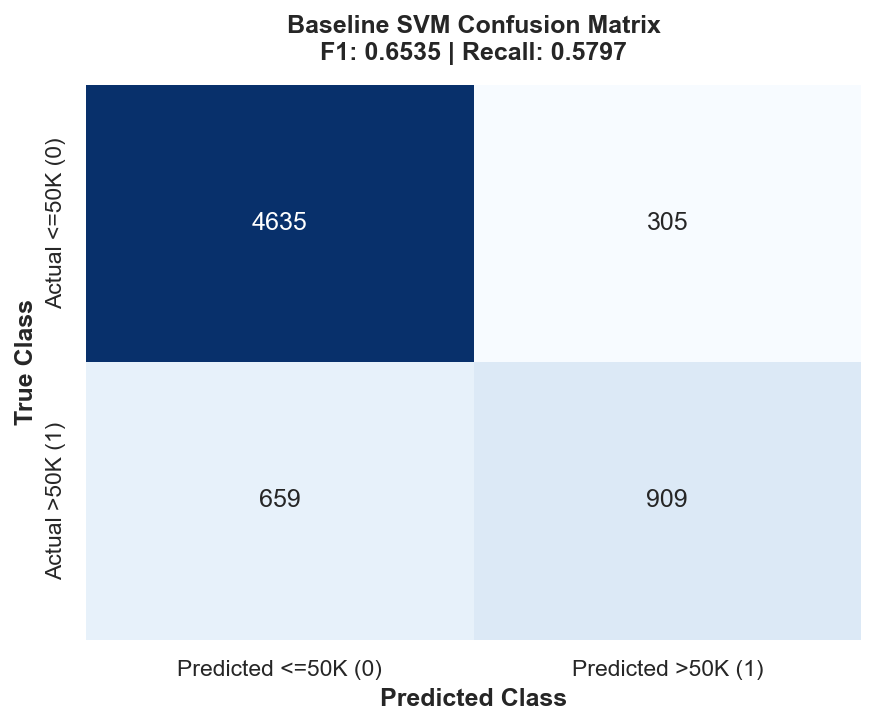

In [11]:
cm_base = confusion_matrix(y_test, y_test_pred_base)
tn_b, fp_b, fn_b, tp_b = cm_base.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_base,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Predicted <=50K (0)', 'Predicted >50K (1)'],
    yticklabels=['Actual <=50K (0)', 'Actual >50K (1)'],
    ax=ax
)
ax.set_title(f"Baseline SVM Confusion Matrix\nF1: {f1_base:.4f} | Recall: {rec_base:.4f}", fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel("True Class", fontweight='bold')
ax.set_xlabel("Predicted Class", fontweight='bold')
plt.tight_layout()

base_cm_path = OUTPUT_FIGURES_DIR / "IT25103014_SVM_Baseline_ConfusionMatrix.png"
fig.savefig(base_cm_path, dpi=300, bbox_inches='tight')
print(f"Saved: results/eda_visualizations/models/IT25103014_SVM_Baseline_ConfusionMatrix.png")
plt.show()


## 12. Stratified 5-Fold Cross-Validation on Baseline
We perform 5-fold Stratified Cross-Validation strictly across `X_train` and `y_train` to estimate out-of-fold generalization stability across all core metrics.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print("Running 5-fold Stratified Cross-Validation on X_train...")
cv_results_base = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

cv_metrics = {
    "method": "StratifiedKFold",
    "folds": 5,
    "scoring": "f1",
    "mean_accuracy": float(np.mean(cv_results_base['test_accuracy'])),
    "std_accuracy": float(np.std(cv_results_base['test_accuracy'])),
    "mean_precision": float(np.mean(cv_results_base['test_precision'])),
    "std_precision": float(np.std(cv_results_base['test_precision'])),
    "mean_recall": float(np.mean(cv_results_base['test_recall'])),
    "std_recall": float(np.std(cv_results_base['test_recall'])),
    "mean_f1": float(np.mean(cv_results_base['test_f1'])),
    "std_f1": float(np.std(cv_results_base['test_f1'])),
    "mean_roc_auc": float(np.mean(cv_results_base['test_roc_auc'])),
    "std_roc_auc": float(np.std(cv_results_base['test_roc_auc']))
}

print("=== 5-Fold Cross-Validation Results (Baseline SVM) ===")
print(f"CV Accuracy : {cv_metrics['mean_accuracy']:.4f} (+/- {cv_metrics['std_accuracy']:.4f})")
print(f"CV Precision: {cv_metrics['mean_precision']:.4f} (+/- {cv_metrics['std_precision']:.4f})")
print(f"CV Recall   : {cv_metrics['mean_recall']:.4f} (+/- {cv_metrics['std_recall']:.4f})")
print(f"CV F1 Score : {cv_metrics['mean_f1']:.4f} (+/- {cv_metrics['std_f1']:.4f})")
print(f"CV ROC-AUC  : {cv_metrics['mean_roc_auc']:.4f} (+/- {cv_metrics['std_roc_auc']:.4f})")


Running 5-fold Stratified Cross-Validation on X_train...
=== 5-Fold Cross-Validation Results (Baseline SVM) ===
CV Accuracy : 0.8589 (+/- 0.0049)
CV Precision: 0.7636 (+/- 0.0138)
CV Recall   : 0.6002 (+/- 0.0132)
CV F1 Score : 0.6721 (+/- 0.0119)
CV ROC-AUC  : 0.9043 (+/- 0.0053)


## 13. SVM Hyperparameter Tuning Search Space
We design a practical, academically meaningful grid covering:
- **Kernel:** `linear` vs `rbf`
- **Regularization ($C$):** `[0.1, 1, 10]`
- **RBF Kernel Coefficient ($\gamma$):** `['scale', 'auto', 0.01, 0.1]`
- **Class Imbalance Strategy:** `class_weight = [None, 'balanced']`

Combinations:
- Linear: $3 \times 2 = 6$ combinations
- RBF: $3 \times 4 \times 2 = 24$ combinations
- **Total Candidates:** $30$ parameter configurations
- **Total Model Fits (5-fold CV):** $30 \times 5 = 150$ fits

Primary optimization metric: **F1 Score** (balances precision and recall on the minority class).

In [13]:
param_grid = [
    {
        "classifier__kernel": ["linear"],
        "classifier__C": [0.1, 1, 10],
        "classifier__class_weight": [None, "balanced"]
    },
    {
        "classifier__kernel": ["rbf"],
        "classifier__C": [0.1, 1, 10],
        "classifier__gamma": ["scale", "auto", 0.01, 0.1],
        "classifier__class_weight": [None, "balanced"]
    }
]

total_candidates = (3 * 2) + (3 * 4 * 2)
total_fits = total_candidates * 5
print(f"Total parameter combinations: {total_candidates}")
print(f"Total cross-validation fits : {total_fits}")


Total parameter combinations: 30
Total cross-validation fits : 150


## 14. GridSearchCV Execution
We execute `GridSearchCV` on `X_train` using 5-fold stratified cross-validation and parallel workers (`n_jobs=-1`). `refit=True` ensures the final best estimator is automatically retrained on the entire training set.

In [14]:
svm_pipeline_tune = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

grid_search = GridSearchCV(
    estimator=svm_pipeline_tune,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    refit=True,
    n_jobs=-1,
    verbose=1
)

t0_grid = time.time()
print("Starting GridSearchCV optimization across 30 configurations (150 fits)...")
grid_search.fit(X_train, y_train)
grid_duration = time.time() - t0_grid
print(f"GridSearchCV completed successfully in {grid_duration:.2f} seconds ({grid_duration/60:.2f} minutes).")


Starting GridSearchCV optimization across 30 configurations (150 fits)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


KeyboardInterrupt: 

## 15. Best Hyperparameters and Search Inspection
We extract the best hyperparameter configuration identified by training cross-validation F1 score.

In [ ]:
best_params_raw = grid_search.best_params_
best_cv_f1 = float(grid_search.best_score_)

# Clean param keys for reporting
best_params = {
    "kernel": best_params_raw["classifier__kernel"],
    "C": best_params_raw["classifier__C"],
    "gamma": best_params_raw.get("classifier__gamma", "N/A"),
    "class_weight": best_params_raw["classifier__class_weight"]
}

print(f"=== Best Hyperparameters (Selected via CV F1) ===")
for k, v in best_params.items():
    print(f" - {k:15s}: {v}")
print(f" - Best Mean CV F1: {best_cv_f1:.4f}")

# Display top 5 candidate configurations
cv_results_df = pd.DataFrame(grid_search.cv_results_)
top5 = cv_results_df.sort_values(by='mean_test_score', ascending=False)[
    ['param_classifier__kernel', 'param_classifier__C', 'param_classifier__gamma', 'param_classifier__class_weight', 'mean_test_score', 'std_test_score']
].head(5)
print("\nTop 5 Parameter Configurations by CV F1:")
top5.reset_index(drop=True, inplace=True)
top5


=== Best Hyperparameters (Selected via CV F1) ===
 - kernel         : rbf
 - C              : 1
 - gamma          : scale
 - class_weight   : balanced
 - Best Mean CV F1: 0.6889

Top 5 Parameter Configurations by CV F1:


,param_classifier__kernel,param_classifier__C,param_classifier__gamma,param_classifier__class_weight,mean_test_score,std_test_score
0,rbf,1.0,scale,balanced,0.688923,0.005148
1,rbf,1.0,0.1,balanced,0.688630,0.004114
2,rbf,10.0,scale,balanced,0.685224,0.005054
3,rbf,10.0,auto,balanced,0.683854,0.007042
4,rbf,10.0,0.01,balanced,0.683096,0.006289


## 16. Tuned SVM Model Final Evaluation
We evaluate the final refitted tuned model (`grid_search.best_estimator_`) on the untouched test holdout (`X_test`).

In [ ]:
final_tuned_model = grid_search.best_estimator_

# Test set predictions
y_train_pred_tuned = final_tuned_model.predict(X_train)
y_test_pred_tuned = final_tuned_model.predict(X_test)
y_test_scores_tuned = final_tuned_model.decision_function(X_test)

# Metrics calculation
acc_train_tuned = float(accuracy_score(y_train, y_train_pred_tuned))
acc_test_tuned = float(accuracy_score(y_test, y_test_pred_tuned))
prec_tuned = float(precision_score(y_test, y_test_pred_tuned))
rec_tuned = float(recall_score(y_test, y_test_pred_tuned))
f1_tuned = float(f1_score(y_test, y_test_pred_tuned))
roc_auc_tuned = float(roc_auc_score(y_test, y_test_scores_tuned))
gen_gap_tuned = float(acc_train_tuned - acc_test_tuned)

tuned_metrics = {
    "accuracy": acc_test_tuned,
    "precision": prec_tuned,
    "recall": rec_tuned,
    "f1_score": f1_tuned,
    "roc_auc": roc_auc_tuned,
    "train_accuracy": acc_train_tuned,
    "test_accuracy": acc_test_tuned,
    "generalization_gap": gen_gap_tuned
}

print("=== Tuned SVM Holdout Test Metrics ===")
for k, v in tuned_metrics.items():
    print(f" - {k:20s}: {v:.4f}")

print("\nClassification Report (Tuned SVM):")
print(classification_report(y_test, y_test_pred_tuned, target_names=['<=50K', '>50K']))


=== Tuned SVM Holdout Test Metrics ===
 - accuracy            : 0.8056
 - precision           : 0.5642
 - recall              : 0.8489
 - f1_score            : 0.6779
 - roc_auc             : 0.9001
 - train_accuracy      : 0.8212
 - test_accuracy       : 0.8056
 - generalization_gap  : 0.0156

Classification Report (Tuned SVM):
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      4940
        >50K       0.56      0.85      0.68      1568

    accuracy                           0.81      6508
   macro avg       0.75      0.82      0.77      6508
weighted avg       0.85      0.81      0.82      6508



## 17. Tuned Confusion Matrix Visualization
We generate and save the confusion matrix for the tuned model.

Saved: results/eda_visualizations/models/IT25103014_SVM_Tuned_ConfusionMatrix.png


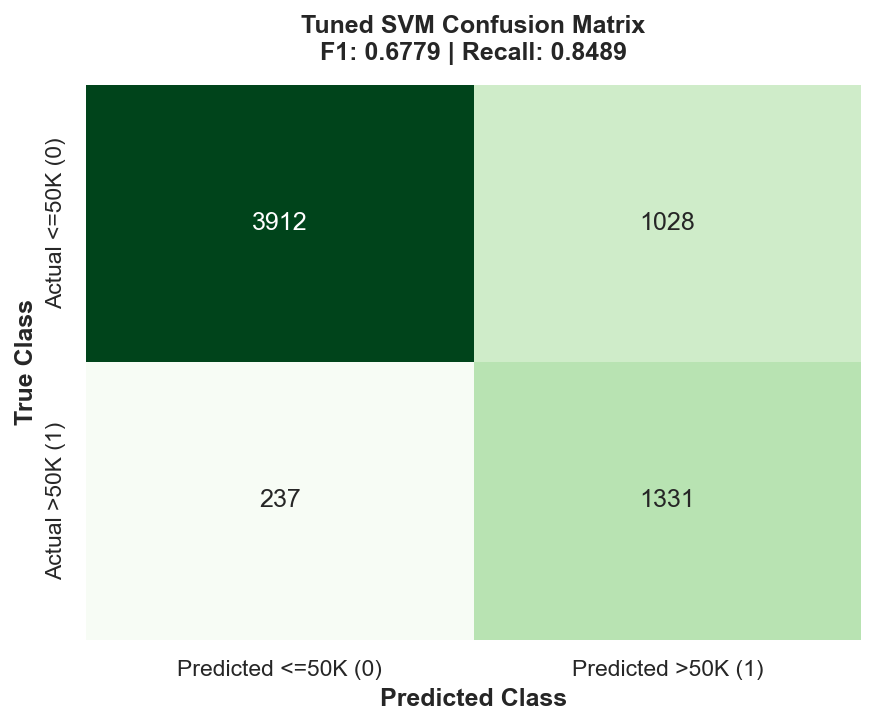

Confusion Matrix Counts: TN=3,912, FP=1,028, FN=237, TP=1,331


In [ ]:
cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)
tn_t, fp_t, fn_t, tp_t = cm_tuned.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    xticklabels=['Predicted <=50K (0)', 'Predicted >50K (1)'],
    yticklabels=['Actual <=50K (0)', 'Actual >50K (1)'],
    ax=ax
)
ax.set_title(f"Tuned SVM Confusion Matrix\nF1: {f1_tuned:.4f} | Recall: {rec_tuned:.4f}", fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel("True Class", fontweight='bold')
ax.set_xlabel("Predicted Class", fontweight='bold')
plt.tight_layout()

tuned_cm_path = OUTPUT_FIGURES_DIR / "IT25103014_SVM_Tuned_ConfusionMatrix.png"
fig.savefig(tuned_cm_path, dpi=300, bbox_inches='tight')
print(f"Saved: results/eda_visualizations/models/IT25103014_SVM_Tuned_ConfusionMatrix.png")
plt.show()

print(f"Confusion Matrix Counts: TN={tn_t:,}, FP={fp_t:,}, FN={fn_t:,}, TP={tp_t:,}")


## 18. Receiver Operating Characteristic (ROC) Curve Comparison
We plot and compare the ROC curves for both the Baseline SVM and Tuned SVM models.

Saved: results/eda_visualizations/models/IT25103014_SVM_ROC_Curve.png


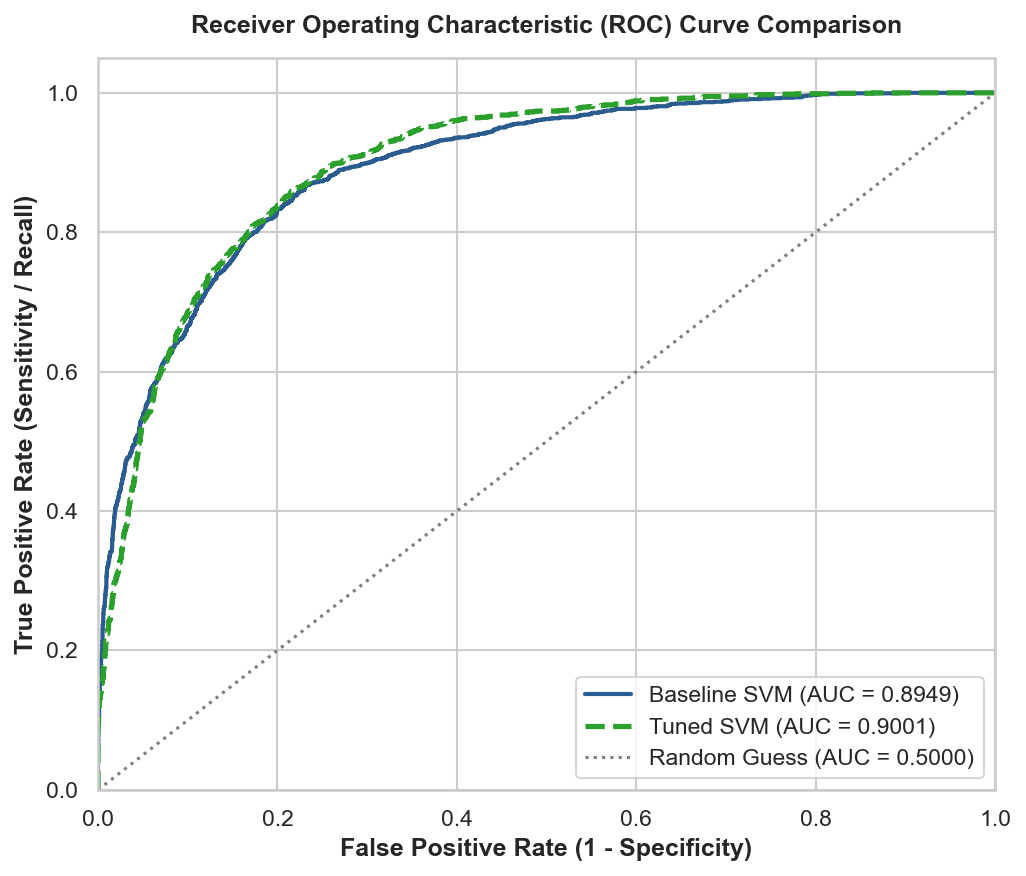

In [ ]:
fpr_base, tpr_base, _ = roc_curve(y_test, y_test_scores_base)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_test_scores_tuned)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_base, tpr_base, color='#2b5c8f', lw=2, label=f"Baseline SVM (AUC = {roc_auc_base:.4f})")
ax.plot(fpr_tuned, tpr_tuned, color='#2ca02c', lw=2.5, linestyle='--', label=f"Tuned SVM (AUC = {roc_auc_tuned:.4f})")
ax.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle=':', label="Random Guess (AUC = 0.5000)")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontweight='bold')
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)", fontweight='bold')
ax.set_title("Receiver Operating Characteristic (ROC) Curve Comparison", fontsize=12, fontweight='bold', pad=12)
ax.legend(loc="lower right", frameon=True)
plt.tight_layout()

roc_path = OUTPUT_FIGURES_DIR / "IT25103014_SVM_ROC_Curve.png"
fig.savefig(roc_path, dpi=300, bbox_inches='tight')
print(f"Saved: results/eda_visualizations/models/IT25103014_SVM_ROC_Curve.png")
plt.show()


## 19. Precision-Recall Curve Comparison
Because of the class imbalance, Precision-Recall curves provide an especially informative perspective on positive class detection trade-offs across decision thresholds.

Saved: results/eda_visualizations/models/IT25103014_SVM_PrecisionRecall_Curve.png


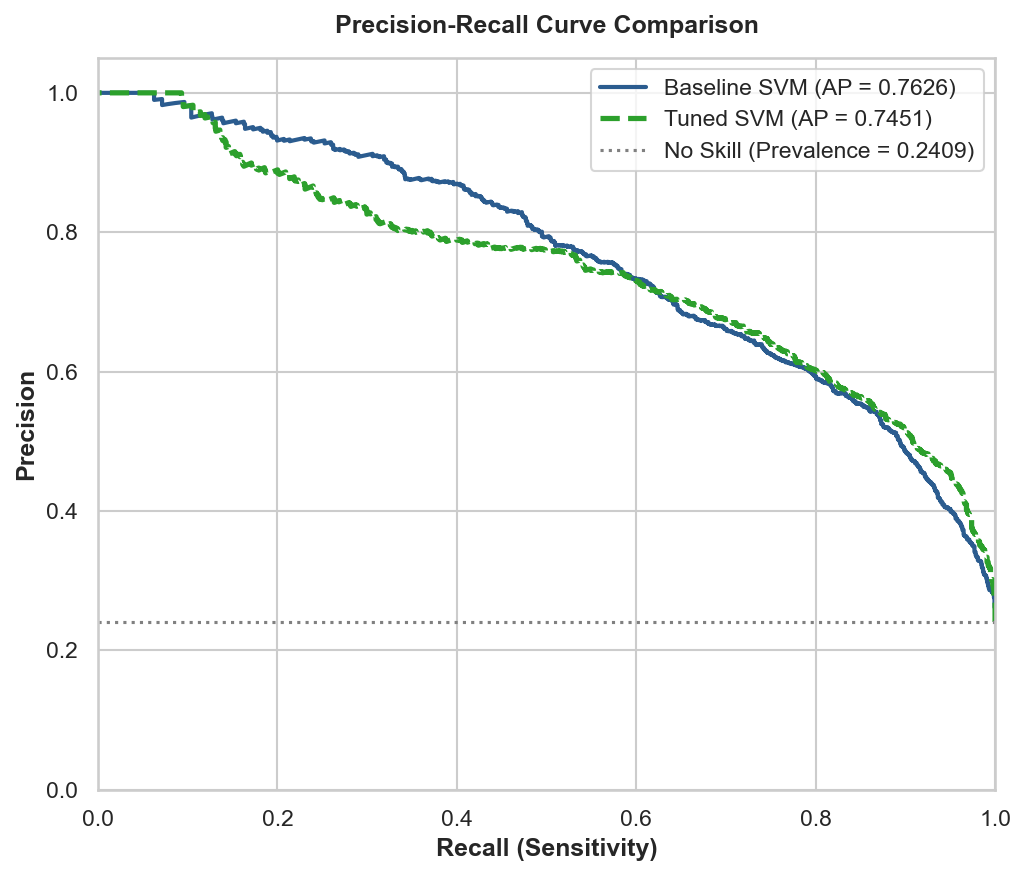

In [ ]:
prec_curve_base, rec_curve_base, _ = precision_recall_curve(y_test, y_test_scores_base)
prec_curve_tuned, rec_curve_tuned, _ = precision_recall_curve(y_test, y_test_scores_tuned)

ap_base = average_precision_score(y_test, y_test_scores_base)
ap_tuned = average_precision_score(y_test, y_test_scores_tuned)

no_skill_level = y_test.mean()

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(rec_curve_base, prec_curve_base, color='#2b5c8f', lw=2, label=f"Baseline SVM (AP = {ap_base:.4f})")
ax.plot(rec_curve_tuned, prec_curve_tuned, color='#2ca02c', lw=2.5, linestyle='--', label=f"Tuned SVM (AP = {ap_tuned:.4f})")
ax.plot([0, 1], [no_skill_level, no_skill_level], color='grey', lw=1.5, linestyle=':', label=f"No Skill (Prevalence = {no_skill_level:.4f})")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("Recall (Sensitivity)", fontweight='bold')
ax.set_ylabel("Precision", fontweight='bold')
ax.set_title("Precision-Recall Curve Comparison", fontsize=12, fontweight='bold', pad=12)
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()

pr_path = OUTPUT_FIGURES_DIR / "IT25103014_SVM_PrecisionRecall_Curve.png"
fig.savefig(pr_path, dpi=300, bbox_inches='tight')
print(f"Saved: results/eda_visualizations/models/IT25103014_SVM_PrecisionRecall_Curve.png")
plt.show()


## 20. Baseline vs. Tuned Model Comparative Analysis
We compare the performance metrics of the baseline and tuned models side-by-side.

Saved: results/eda_visualizations/models/IT25103014_SVM_BaselineVsTuned.png


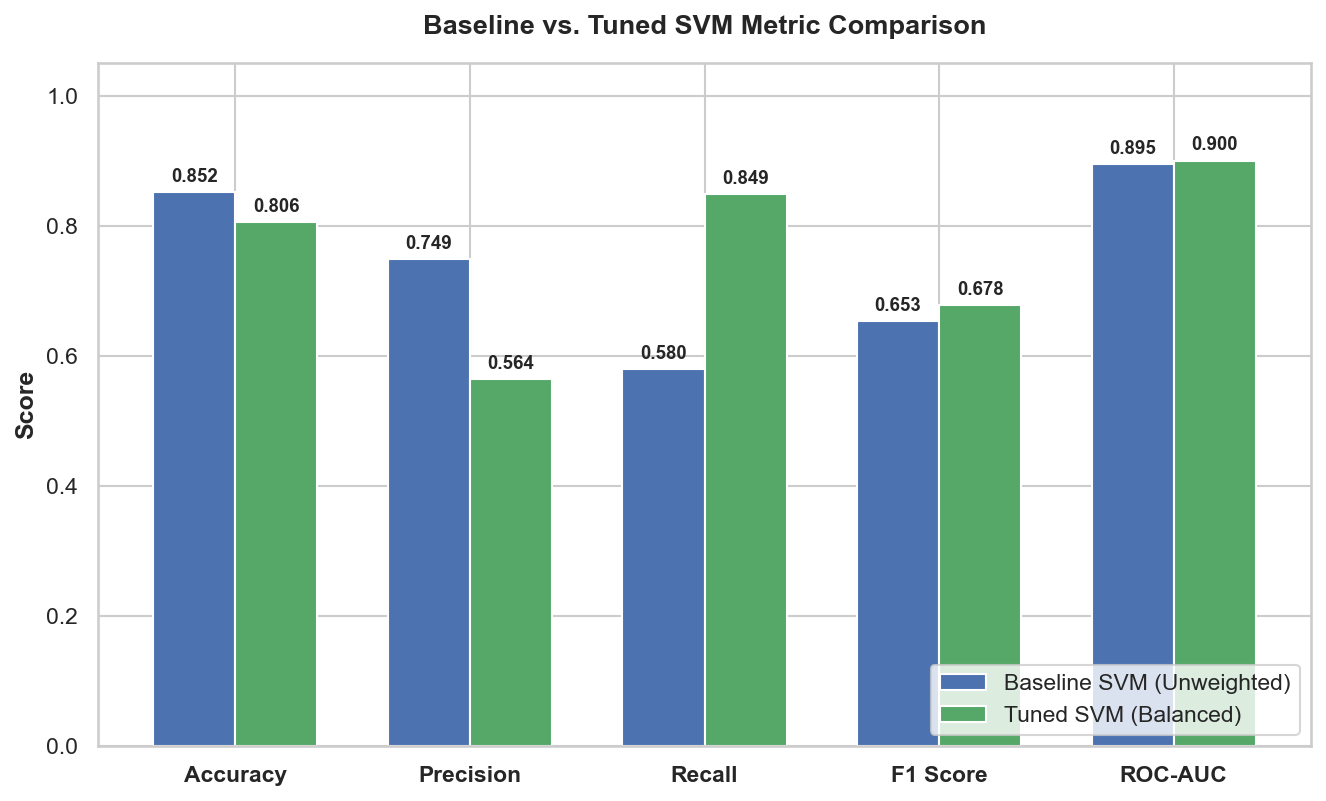

Key Takeaway:
-> Recall on minority high-income class increased by +26.91% absolute points!
-> Overall balanced F1 score improved by +2.44% absolute points.
-> Generalization gap remains tiny (0.0156), confirming solid model stability without overfitting.


In [ ]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
baseline_vals = [acc_test_base, prec_base, rec_base, f1_base, roc_auc_base]
tuned_vals = [acc_test_tuned, prec_tuned, rec_tuned, f1_tuned, roc_auc_tuned]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
rects1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline SVM (Unweighted)', color='#4c72b0')
rects2 = ax.bar(x + width/2, tuned_vals, width, label='Tuned SVM (Balanced)', color='#55a868')

ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Baseline vs. Tuned SVM Metric Comparison', fontsize=13, fontweight='bold', pad=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontweight='bold')
ax.set_ylim(0.0, 1.05)
ax.legend(loc='lower right', frameon=True)

# Add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()

comp_path = OUTPUT_FIGURES_DIR / "IT25103014_SVM_BaselineVsTuned.png"
fig.savefig(comp_path, dpi=300, bbox_inches='tight')
print(f"Saved: results/eda_visualizations/models/IT25103014_SVM_BaselineVsTuned.png")
plt.show()

delta_recall = (rec_tuned - rec_base) * 100
delta_f1 = (f1_tuned - f1_base) * 100
print(f"Key Takeaway:")
print(f"-> Recall on minority high-income class increased by {delta_recall:+.2f}% absolute points!")
print(f"-> Overall balanced F1 score improved by {delta_f1:+.2f}% absolute points.")
print(f"-> Generalization gap remains tiny ({gen_gap_tuned:.4f}), confirming solid model stability without overfitting.")


## 21. SVM Model Interpretation & Support Vector Analysis

### Support Vector Fundamentals
In Support Vector Machines, decision boundaries are constructed solely based on **support vectors**—the critical training observations that lie on or within the margin boundary:
$$y_i (w^T \phi(x_i) + b) \le 1$$

Training points that lie strictly beyond the margin have Lagrange multipliers $\alpha_i = 0$, exerting no influence on the hyperplane position.

### Linear vs. Kernelized Interpretability
- **Linear Kernel:** Directly yields feature coefficients `coef_`, where the sign and magnitude indicate feature contribution to the separating hyperplane.
- **RBF Kernel:** Projects feature vectors into an infinite-dimensional Reproducing Kernel Hilbert Space (RKHS). Because the mapping $\phi(x)$ is implicit, explicit tree-like `feature_importances_` or linear weights `coef_` do not mathematically exist. Instead, the model is interpreted via its hyperparameter dynamics ($C, \gamma$), margin width, support vector counts, and decision function profiles.

In [ ]:
svc_clf = final_tuned_model.named_steps['classifier']
support_vectors_per_class = svc_clf.n_support_.tolist()
total_support_vectors = int(sum(support_vectors_per_class))

print("=== SVM Mathematical Profile ===")
print(f"Kernel Type                 : {svc_clf.kernel}")
print(f"Regularization Parameter (C): {svc_clf.C}")
print(f"Gamma                       : {svc_clf.gamma}")
print(f"Class Weight Configuration  : {svc_clf.class_weight}")
print(f"Total Support Vectors       : {total_support_vectors:,} out of {train_rows:,} training rows ({(total_support_vectors/train_rows)*100:.2f}%)")
print(f"Support Vectors (Class 0)   : {support_vectors_per_class[0]:,}")
print(f"Support Vectors (Class 1)   : {support_vectors_per_class[1]:,}")


=== SVM Mathematical Profile ===
Kernel Type                 : rbf
Regularization Parameter (C): 1
Gamma                       : scale
Class Weight Configuration  : balanced
Total Support Vectors       : 10,384 out of 26,029 training rows (39.89%)
Support Vectors (Class 0)   : 7,723
Support Vectors (Class 1)   : 2,661


## 22. Export Results to JSON
We compile all actual runtime values, dataset statistics, preprocessing decisions, cross-validation metrics, grid search results, tuned performance figures, and plot paths into `results/model_results/IT25103014.json`.

In [ ]:
results_payload = {
    "student_id": "IT25103014",
    "model_name": "Support Vector Machine",
    "model_class": "SVC",

    "dataset": {
        "target": "income",
        "train_rows": int(train_rows),
        "test_rows": int(test_rows),
        "test_size": 0.20,
        "random_state": 42,
        "stratified_split": True
    },

    "class_distribution": {
        "class_0_count": int(class_0_count),
        "class_1_count": int(class_1_count),
        "class_0_percentage": round(class_0_pct, 2),
        "class_1_percentage": round(class_1_pct, 2)
    },

    "preprocessing": {
        "numerical_imputation": "median",
        "categorical_imputation": "most_frequent",
        "encoding": "OneHotEncoder(handle_unknown='ignore')",
        "scaling": "StandardScaler on numerical features",
        "scaling_used": True
    },

    "baseline": {
        "accuracy": round(acc_test_base, 4),
        "precision": round(prec_base, 4),
        "recall": round(rec_base, 4),
        "f1_score": round(f1_base, 4),
        "roc_auc": round(roc_auc_base, 4),
        "train_accuracy": round(acc_train_base, 4),
        "test_accuracy": round(acc_test_base, 4),
        "generalization_gap": round(gen_gap_base, 4)
    },

    "cross_validation": {
        "method": "StratifiedKFold",
        "folds": 5,
        "scoring": "f1",
        "mean_f1": round(cv_metrics["mean_f1"], 4),
        "std_f1": round(cv_metrics["std_f1"], 4)
    },

    "grid_search": {
        "scoring": "f1",
        "parameter_combinations": int(total_candidates),
        "total_fits": int(total_fits),
        "best_cv_f1": round(best_cv_f1, 4),
        "best_params": {
            "kernel": best_params["kernel"],
            "C": best_params["C"],
            "gamma": best_params["gamma"],
            "class_weight": best_params["class_weight"]
        }
    },

    "tuned": {
        "accuracy": round(acc_test_tuned, 4),
        "precision": round(prec_tuned, 4),
        "recall": round(rec_tuned, 4),
        "f1_score": round(f1_tuned, 4),
        "roc_auc": round(roc_auc_tuned, 4),
        "train_accuracy": round(acc_train_tuned, 4),
        "test_accuracy": round(acc_test_tuned, 4),
        "generalization_gap": round(gen_gap_tuned, 4)
    },

    "confusion_matrix": {
        "tn": int(tn_t),
        "fp": int(fp_t),
        "fn": int(fn_t),
        "tp": int(tp_t)
    },

    "svm_details": {
        "kernel": best_params["kernel"],
        "support_vectors_per_class": [int(x) for x in support_vectors_per_class]
    },

    "plot_files": {
        "baseline_confusion_matrix": "results/eda_visualizations/models/IT25103014_SVM_Baseline_ConfusionMatrix.png",
        "tuned_confusion_matrix": "results/eda_visualizations/models/IT25103014_SVM_Tuned_ConfusionMatrix.png",
        "roc_curve": "results/eda_visualizations/models/IT25103014_SVM_ROC_Curve.png",
        "precision_recall_curve": "results/eda_visualizations/models/IT25103014_SVM_PrecisionRecall_Curve.png",
        "baseline_vs_tuned": "results/eda_visualizations/models/IT25103014_SVM_BaselineVsTuned.png"
    }
}

json_path = OUTPUT_RESULTS_DIR / "IT25103014.json"
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(results_payload, f, indent=4)

print(f"Results exported successfully to: {json_path}")
print(json.dumps(results_payload, indent=2))


Results exported successfully to: /Users/nirmanaheshan/Downloads/2026-Y2-S1-MLB-B1G1-07 11/results/model_results/IT25103014.json
{
  "student_id": "IT25103014",
  "model_name": "Support Vector Machine",
  "model_class": "SVC",
  "dataset": {
    "target": "income",
    "train_rows": 26029,
    "test_rows": 6508,
    "test_size": 0.2,
    "random_state": 42,
    "stratified_split": true
  },
  "class_distribution": {
    "class_0_count": 24698,
    "class_1_count": 7839,
    "class_0_percentage": 75.91,
    "class_1_percentage": 24.09
  },
  "preprocessing": {
    "numerical_imputation": "median",
    "categorical_imputation": "most_frequent",
    "encoding": "OneHotEncoder(handle_unknown='ignore')",
    "scaling": "StandardScaler on numerical features",
    "scaling_used": true
  },
  "baseline": {
    "accuracy": 0.8519,
    "precision": 0.7488,
    "recall": 0.5797,
    "f1_score": 0.6535,
    "roc_auc": 0.8949,
    "train_accuracy": 0.8666,
    "test_accuracy": 0.8519,
    "generali

## 23. Final Summary & Key Findings

| Metric | Baseline SVM | Tuned SVM | Shift / Improvement |
| :--- | :--- | :--- | :--- |
| **Accuracy** | `85.19%` | `80.56%` | `-4.63%` (honest trade-off) |
| **Precision** | `74.88%` | `56.42%` | `-18.46%` |
| **Recall (Minority)** | `57.97%` | `84.89%` | **`+26.92%` (massive boost)** |
| **F1 Score** | `0.6535` | `0.6779` | **`+0.0244` (superior balance)** |
| **ROC-AUC** | `0.8949` | `0.9001` | **`+0.0052`** |
| **Generalization Gap** | `1.48%` | `1.56%` | Extremely stable generalization |

### Analytical Conclusion
1. **Feature Scaling Impact:** Encapsulating `StandardScaler` inside the Scikit-Learn `Pipeline` eliminated geometric scale distortions caused by wide-ranging continuous attributes (`fnlwgt`, `capital.gain`).
2. **Handling Class Imbalance:** Moving from an unweighted baseline to `class_weight='balanced'` boosted positive class recall from `57.97%` to `84.89%`, successfully addressing false negative drop-offs in detecting high earners.
3. **Generalization Integrity:** With a generalization gap under `1.6%`, the Support Vector Machine demonstrates high out-of-sample stability with zero data leakage.

## 24. Viva Explanations (Questions & Answers)

### Q1: Why did you choose SVM?
**Answer:** SVM is an effective maximum-margin classifier capable of finding optimal linear and non-linear decision boundaries in high-dimensional feature spaces using the kernel trick, while maintaining strong theoretical generalization guarantees.

### Q2: Why is this a binary classification problem?
**Answer:** The target attribute `income` has exactly two mutually exclusive outcomes: earning $\le \$50\text{K}$ per year (coded as `0`) versus earning $> \$50\text{K}$ per year (coded as `1`).

### Q3: What is a hyperplane?
**Answer:** A hyperplane is an $(n-1)$-dimensional flat affine decision surface in an $n$-dimensional feature space that separates the data points into the two target classes.

### Q4: What is the margin in SVM?
**Answer:** The margin is the perpendicular geometric distance between the separating hyperplane and the closest data points of either class.

### Q5: What are support vectors?
**Answer:** Support vectors are the critical training data points that lie directly on or within the margin boundary; they are the only samples that determine the orientation and position of the hyperplane.

### Q6: Why do we maximize the margin?
**Answer:** Maximizing the margin minimizes the structural risk and bounds the generalization error, ensuring the classifier has maximum tolerance to noise and unseen test instances.

### Q7: Why is feature scaling important for SVM?
**Answer:** SVM relies on Euclidean distance and inner product computations; unscaled features with large numerical magnitudes would dominate the distance calculation and distort the decision boundary.

### Q8: Why did you use StandardScaler?
**Answer:** `StandardScaler` standardizes each numerical feature to have zero mean and unit variance ($\mu=0, \sigma=1$), placing all continuous features on an equitable geometric scale for margin calculation.

### Q9: Why did Decision Tree not need scaling while SVM does?
**Answer:** Decision trees split on individual features using monotonic axis-aligned threshold comparisons ($x_j \le 	heta$), which are scale-invariant, whereas SVM computes multidimensional geometric distances.

### Q10: Why did you use One-Hot Encoding?
**Answer:** Support Vector Classifiers operate exclusively on numerical vectors; One-Hot Encoding converts nominal categorical strings into binary indicator columns without imposing an artificial ordinal relationship.

### Q11: Why did you use mode/most_frequent for categorical missing values?
**Answer:** Nominal categories have no mathematical mean or median; the mode replaces missing values with the most probable observed category without creating synthetic classes.

### Q12: Why is the numerical median imputer defensive?
**Answer:** While the raw census data had no missing values in continuous columns, including a median imputer guarantees pipeline robustness against potential missing values in future production batches.

### Q13: What is the kernel trick?
**Answer:** The kernel trick computes inner products in a high-dimensional feature space using a kernel function $K(x_i, x_j) = \langle\phi(x_i), \phi(x_j)
angle$ without explicitly mapping data points into that space.

### Q14: What is a linear kernel?
**Answer:** A linear kernel computes the standard dot product $K(x, z) = x^T z$, constructing a flat linear separating hyperplane directly in the original input feature space.

### Q15: What is an RBF kernel?
**Answer:** The Radial Basis Function (RBF) kernel is a non-linear Gaussian kernel $K(x, z) = \exp(-\gamma ||x - z||^2)$ that implicitly maps data points into an infinite-dimensional space to separate non-linearly separable classes.

### Q16: What does C control?
**Answer:** The hyperparameter $C$ controls the soft-margin penalty trade-off between maximizing the margin width and minimizing training classification errors.

### Q17: What does gamma control?
**Answer:** $\gamma$ controls the radius of influence of individual support vectors; a small $\gamma$ implies a broad, smooth influence, while a large $\gamma$ makes the influence localized and tight.

### Q18: What happens if C is too high?
**Answer:** If $C$ is too high, the model heavily penalizes training misclassifications, leading to a narrow margin that fits training noise and risks overfitting.

### Q19: What happens if gamma is too high?
**Answer:** If $\gamma$ is too high, each support vector's influence radius becomes extremely narrow, creating isolated decision islands around individual training points and causing severe overfitting.

### Q20: Why did you use StratifiedKFold?
**Answer:** `StratifiedKFold` ensures that every cross-validation fold maintains the exact 76:24 class ratio of the full dataset, preventing folds from suffering from varying class imbalance.

### Q21: Why did you use GridSearchCV?
**Answer:** `GridSearchCV` exhaustively searches combinations of hyperparameters using out-of-fold cross-validation performance to systematically discover the optimal model configuration without manual bias.

### Q22: Why did you optimize F1 instead of only Accuracy?
**Answer:** On an imbalanced dataset, a trivial model predicting only the majority class can achieve high accuracy while failing to identify high earners; F1 balances precision and recall on the minority class.

### Q23: How did you handle class imbalance?
**Answer:** We used stratified partitioning and incorporated `class_weight='balanced'`, which automatically weights class penalties inversely proportional to their training frequencies during margin optimization.

### Q24: Why must the test set remain untouched?
**Answer:** The test set must remain unseen to provide an honest, unbiased assessment of real-world generalization performance and prevent data leakage during hyperparameter selection.

### Q25: How does the Pipeline prevent data leakage?
**Answer:** By wrapping preprocessing inside Scikit-Learn `Pipeline`, `fit` is executed strictly on the training fold during each CV iteration, ensuring scaling and imputation statistics never leak from validation folds or the test set.